<a href="https://colab.research.google.com/github/maurocollin/bigdata-saude-niteroi/blob/main/TRAB_PRONTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Faculdade Estácio de Sá
## **Curso:** Análise e Desenvolvimento de Sistemas
### **Disciplina:** Tópicos de Big Data em Python

---

# 📊 **PROJETO EXTENSIONISTA**
## **Tema:** Análise de Indicadores de Saúde Municipal Pública e Privada
### *Previsão de Demandas por Bairro em Niterói-RJ*

---

### **Corpo Docente:**
* **Profª Simone Gama**

### **Corpo Discente (Grupo):**
| Nome | Matrícula |
| :--- | :--- |
| **Hudson Mata Neves** | 202402852175 |
| **Mauro Henrique Collin Ferreira** | 202403689601 |

---
> **Local:** Niterói, RJ - 2026

# ETAPA 1: GOVERNANÇA, INGESTÃO E DIAGNÓSTICO ESTRUTURAL

Nesta fase inicial de **Governança de Dados**, estabelecemos o ambiente de análise e a ingestão automatizada dos dados via repositório remoto (GitHub). Esta abordagem é um pilar fundamental em projetos de **Big Data Analytics**, pois garante a **Reprodutibilidade Técnica**: o estudo pode ser auditado e executado por outros pesquisadores em qualquer ambiente, sem dependências de arquivos locais.

**Objetivos desta etapa:**
* **Ingestão Multi-Fonte:** Carregamento de bases provenientes de diferentes órgãos (IBGE, CNES e Prefeitura de Niterói).
* **Diagnóstico de Estrutura:** Identificação do volume de dados (contagem de linhas e colunas) e da tipagem das variáveis. Este mapeamento é obrigatório para assegurar a integridade das operações matemáticas e estatísticas que serão realizadas nas etapas subsequentes.
* **Consistência de Tipos:** Verificação inicial para garantir que variáveis numéricas e categóricas foram interpretadas corretamente pelo interpretador Python.

## 📂 Fontes de Dados
Os dados foram obtidos de bases governamentais oficiais e são consumidos diretamente deste repositório para garantir a **reprodutibilidade** e a precisão da análise:

* `Agregados_por_bairros_basico_BR.csv`: * **Dados Demográficos (IBGE):** [Censo 2022 - Agregados por Bairros](https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios/Agregados_por_Bairro_csv/Agregados_por_bairros_basico_BR_20250417.zip)
    * *Dicionário de dados:* [IBGE Dicionário](https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios/dicionario_de_dados_agregados_por_setores_censitarios_20250417.xlsx)
* `CNES_Leitos_Niteroi.csv`: * **Capacidade Hospitalar (DATASUS/CNES):** [CNES - Base de Dados de Leitos](https://cnes.datasus.gov.br/pages/downloads/arquivosBaseDados.jsp)
    * *Dicionário de dados:* [CNES Dicionário](https://cnes.datasus.gov.br/EstatisticasServlet?path=SCNES_DICIONARIO_DE_DADOS.ZIP)
* **Infraestrutura de Saúde (SIGeo Niterói):**
* `Hospitais.csv`: * [Hospitais de Niterói](https://www.sigeo.niteroi.rj.gov.br/maps/7636a753146a426ba56aa15ef086e178)
* `Policlinicas.csv`:  * [Policlínicas de Niterói](https://www.sigeo.niteroi.rj.gov.br/maps/c7f2ebff746a4b1fb3a69999b8c04598)
* `Unidades_Basicas_de_Saude_UBS.csv`:    * [Unidades Básicas de Saúde (UBS)](https://www.sigeo.niteroi.rj.gov.br/maps/c6c3183b85a24e1bb46a17d89aa55d5f)

In [1]:
# ==============================================================================
# ETAPA 1: SETUP E EXTRAÇÃO DOS DADOS
# ==============================================================================
# Instalação de bibliotecas extras necessárias para os mapas
!pip install geobr folium pyproj -q
import pandas as pd
import numpy as np
import unicodedata
import geobr
import folium
from pyproj import Transformer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

print("Iniciando a extração dos dados do GitHub...")

# URL base do repositório
url_base = 'https://raw.githubusercontent.com/maurocollin/bigdata-saude-niteroi/main/'

# Leitura dos arquivos CSV
df_pop = pd.read_csv(f'{url_base}Agregados_por_bairros_basico_BR.csv', sep=';', encoding='latin1', on_bad_lines='skip')
df_ubs = pd.read_csv(f'{url_base}Unidades_Basicas_de_Saude_UBS.csv', encoding='utf-8')
df_hosp = pd.read_csv(f'{url_base}Hospitais.csv', encoding='utf-8')
df_poli = pd.read_csv(f'{url_base}Policlinicas.csv', encoding='utf-8')
df_leitos = pd.read_csv(f'{url_base}CNES_Leitos_Niteroi.csv', encoding='utf-8')

print("✅ Bases carregadas com sucesso!")

# ==============================================================================
# DIAGNÓSTICO DE ESTRUTURA
# ==============================================================================
print("\n--- ESTRUTURA DAS BASES DE DADOS ---")

# Incluindo todas as bases carregadas para o diagnóstico completo
bases = {
    "População (IBGE)": df_pop,
    "UBS": df_ubs,
    "Hospitais": df_hosp,
    "Policlínicas": df_poli,
    "Leitos Hospitalares": df_leitos
}

for nome, df in bases.items():
    print(f"\n📊 Base: {nome}")
    print(f"• Linhas: {df.shape[0]}")
    print(f"• Colunas: {df.shape[1]}")
    print("• Tipos de Variáveis:")
    print(df.dtypes.head(5))
    print("-" * 40)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.7 MB/s eta 0:00:00
Iniciando a extração dos dados do GitHub...
✅ Bases carregadas com sucesso!

--- ESTRUTURA DAS BASES DE DADOS ---

📊 Base: População (IBGE)
• Linhas: 17576
• Colunas: 30
• Tipos de Variáveis:
CD_BAIRRO     int64
NM_BAIRRO    object
CD_REGIAO     int64
NM_REGIAO    object
CD_UF         int64
dtype: object
----------------------------------------

📊 Base: UBS
• Linhas: 11
• Colunas: 20
• Tipos de Variáveis:
fid            int64
cnes           int64
nome          object
nome_gen      object
tipunidade    object
dtype: object
----------------------------------------

📊 Base: Hospitais
• Linhas: 20
• Colunas: 10
• Tipos de Variáveis:
X              float64
Y              float64
OBJECTID         int64
tx_nome         object
tx_endereco     object
dtype: object


# ETAPA 2: AUDITORIA DE INTEGRIDADE E QUALIDADE DE DADOS

Nesta fase, realizamos uma **Auditoria de Integridade Técnica** para identificar inconsistências estruturais nas fontes de dados antes de qualquer transformação. Este processo é fundamental no ciclo de **Big Data Analytics** (Temas 3, 4 e 5) para mitigar o risco de *Garbage In, Garbage Out*.

O relatório abaixo foca em dois pilares críticos:
* **Valores Ausentes (Missing Data):** Identificação de campos nulos que podem enviesar as métricas de saúde.
* **Registros Duplicados:** Verificação de redundâncias que poderiam inflar artificialmente a capacidade instalada do município.

A identificação precoce dessas falhas permite validar as estratégias de limpeza e assegurar que o modelo de regressão e os indicadores da OMS sejam baseados em dados íntegros.

In [2]:
# ==============================================================================
# ETAPA 2: RELATÓRIO DE QUALIDADE E INTEGRIDADE (AUDITORIA PRÉ-LIMPEZA)
# ==============================================================================
print("-" * 60)
print("🔍 RELATÓRIO DE QUALIDADE DE DADOS (DIAGNÓSTICO INICIAL)")
print("-" * 60)

# O dicionário 'bases' deve ter sido definido na Etapa 1
for nome, df in bases.items():
    total_nulos = df.isnull().sum().sum()
    total_duplicados = df.duplicated().sum()

    print(f"\n📂 Base: {nome}")
    print(f"• Total de valores nulos: {total_nulos}")
    print(f"• Total de registros duplicados: {total_duplicados}")

    # Detalhamento por coluna para transparência acadêmica
    if total_nulos > 0:
        print("  ↳ Campos ausentes detectados por coluna:")
        contagem_nulos = df.isnull().sum()
        # Exibindo apenas as colunas que possuem falhas para manter o log limpo
        print(contagem_nulos[contagem_nulos > 0])

    print("-" * 40)

print("\n✅ Auditoria concluída. Iniciando processos de limpeza e padronização...")

# ------------------------------------------------------------------------------
# Início do Processo de Limpeza e Regras de Negócio
# ------------------------------------------------------------------------------

# 1. Função normalizar strings
def normalizar_bairro(nome):
    if pd.isna(nome): return ''
    nome = str(nome).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', nome) if unicodedata.category(c) != 'Mn')

# 2. Aplicando a normalização nas bases de saúde
df_hosp['BAIRRO_NORM'] = df_hosp['tx_bairro'].apply(normalizar_bairro)
df_poli['BAIRRO_NORM'] = df_poli['bairro'].apply(normalizar_bairro)
df_ubs['BAIRRO_NORM'] = df_ubs['bairro'].apply(normalizar_bairro)

# 3. Classificação de Gestão (Pública vs Privada)
def categorizar_gestao(nome):
    nome = str(nome).upper()
    palavras_publicas = ['MUNICIPAL', 'ESTADUAL', 'FEDERAL', 'UNIVERSITÁRIO', 'POLÍCIA MILITAR']
    excecoes_publicas = ['HOSPITAL PSIQUIÁTRICO DE JURUJUBA', 'HOSPITAL GETULIO VARGAS FILHO', 'HOSPITAL ORÊNCIO DE FREITAS']

    if any(palavra in nome for palavra in palavras_publicas) or any(exc in nome for exc in excecoes_publicas):
        return 'Pública'
    return 'Privada'

df_hosp['Tipo_Unidade'] = df_hosp['tx_nome'].apply(categorizar_gestao)
df_poli['Tipo_Unidade'] = 'Pública'
df_ubs['Tipo_Unidade'] = 'Pública'

# 4. Limpeza e Tratamento da Base de População (IBGE)
df_niteroi = df_pop[df_pop['NM_MUN'] == 'Niterói'].copy()
df_niteroi['BAIRRO_NORM'] = df_niteroi['NM_BAIRRO'].apply(normalizar_bairro)
df_niteroi['POPULACAO'] = pd.to_numeric(df_niteroi['v0001'].astype(str).str.replace(',', '.'), errors='coerce')

# Tratando nulos identificados na auditoria inicial
df_niteroi['POPULACAO'] = df_niteroi['POPULACAO'].fillna(0)

print("\n✅ Padronização, limpeza e classificação de gestão concluídas com sucesso!")

------------------------------------------------------------
🔍 RELATÓRIO DE QUALIDADE DE DADOS (DIAGNÓSTICO INICIAL)
------------------------------------------------------------

📂 Base: População (IBGE)
• Total de valores nulos: 56585
• Total de registros duplicados: 0
  ↳ Campos ausentes detectados por coluna:
NM_SUBDIST    14604
NM_NU         17169
NM_AGLOM      17411
NM_CONCURB     7401
dtype: int64
----------------------------------------

📂 Base: UBS
• Total de valores nulos: 0
• Total de registros duplicados: 0
----------------------------------------

📂 Base: Hospitais
• Total de valores nulos: 0
• Total de registros duplicados: 0
----------------------------------------

📂 Base: Policlínicas
• Total de valores nulos: 0
• Total de registros duplicados: 0
----------------------------------------

📂 Base: Leitos Hospitalares
• Total de valores nulos: 1762
• Total de registros duplicados: 0
  ↳ Campos ausentes detectados por coluna:
REGSAUDE    194
MICR_REG    196
DISTRSAN    196


# ETAPA 3: CONSOLIDAÇÃO DA TABELA ANALÍTICA E AUDITORIA DE QUALIDADE

Nesta etapa, realizamos o cruzamento (*merge*) das fontes de dados tratadas para gerar a **Tabela Analítica Consolidada**. Este processo envolve a agregação das unidades de saúde por bairro e a junção com a base demográfica do IBGE.

Para garantir o rigor exigido nos **Temas 3, 4 e 5** do documento extensionista, implementamos uma **Auditoria Pós-Tratamento**. O objetivo é verificar se a integridade dos dados foi mantida após o cruzamento, assegurando que não restaram valores nulos ou registros órfãos que possam comprometer a acurácia da Regressão Linear e das análises subsequentes. Esta fase blinda o projeto contra erros estatísticos invisíveis.

In [3]:
# ==============================================================================
# ETAPA 3: AGREGAÇÃO, CRUZAMENTO E AUDITORIA FINAL DE QUALIDADE
# ==============================================================================

# 1. Consolidar todas as unidades de saúde em uma única estrutura
unidades = []
for _, row in df_hosp.iterrows(): unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})
for _, row in df_poli.iterrows(): unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})
for _, row in df_ubs.iterrows():  unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})

df_unidades = pd.DataFrame(unidades)

# 2. Agregação: Contar unidades por Bairro e Tipo (Público/Privado)
df_saude_bairro = df_unidades.groupby(['Bairro', 'Tipo']).size().unstack(fill_value=0).reset_index()

# Garantir que as colunas existam mesmo se uma delas for zero
for col in ['Privada', 'Pública']:
    if col not in df_saude_bairro.columns: df_saude_bairro[col] = 0

df_saude_bairro['Total_Unidades'] = df_saude_bairro['Pública'] + df_saude_bairro['Privada']

# 3. Cruzamento (Merge) da População com os Dados de Saúde
df_pop_resumo = df_niteroi[['BAIRRO_NORM', 'NM_BAIRRO', 'POPULACAO']]
df_final = pd.merge(df_pop_resumo, df_saude_bairro, left_on='BAIRRO_NORM', right_on='Bairro', how='left')

# Tratando bairros sem unidades (NaN vira 0)
df_final[['Privada', 'Pública', 'Total_Unidades']] = df_final[['Privada', 'Pública', 'Total_Unidades']].fillna(0)

# --- AUDITORIA FINAL DE QUALIDADE ---
print("-" * 60)
print("🛡️ AUDITORIA DE INTEGRIDADE PÓS-PROCESSAMENTO")
print("-" * 60)

nulos_finais = df_final[['POPULACAO', 'Total_Unidades']].isnull().sum().sum()
duplicados_finais = df_final.duplicated().sum()

if nulos_finais == 0 and duplicados_finais == 0:
    print(f"✅ SUCESSO: Tabela Analítica consolidada com {df_final.shape[0]} bairros.")
    print("✅ QUALIDADE: Zero valores nulos ou duplicados nas colunas críticas.")
else:
    print(f"⚠️ ALERTA: Detectadas falhas após o merge ({nulos_finais} nulos).")

print("-" * 60)

# Amostragem para conferência
display(df_final.sort_values(by='POPULACAO', ascending=False).head(5))

------------------------------------------------------------
🛡️ AUDITORIA DE INTEGRIDADE PÓS-PROCESSAMENTO
------------------------------------------------------------
✅ SUCESSO: Tabela Analítica consolidada com 52 bairros.
✅ QUALIDADE: Zero valores nulos ou duplicados nas colunas críticas.
------------------------------------------------------------


,BAIRRO_NORM,NM_BAIRRO,POPULACAO,Bairro,Privada,Pública,Total_Unidades
17,ICARAI,Icaraí,77247,ICARAI,1.0,0.0,1.0
15,FONSECA,Fonseca,46317,FONSECA,2.0,4.0,6.0
37,SANTA ROSA,Santa Rosa,34112,SANTA ROSA,1.0,1.0,2.0
2,BARRETO,Barreto,18699,BARRETO,1.0,5.0,6.0
32,PIRATININGA,Piratininga,18492,PIRATININGA,0.0,3.0,3.0


# ETAPA 4: ESTATÍSTICA DESCRITIVA E DISTRIBUIÇÃO DE FREQUÊNCIAS

Nesta fase, aplicamos as **Medidas de Tendência Central (Média e Mediana)** e de **Dispersão (Desvio Padrão, Mínimo e Máximo)** para compreender o comportamento das variáveis quantitativas do projeto. O objetivo é estabelecer o perfil demográfico e assistencial médio dos bairros de Niterói.

Além da análise numérica, realizamos a **Análise de Variáveis Categóricas**, calculando a distribuição de frequências da rede de saúde. Esta distinção é fundamental para o **Trabalho Extensionista**, pois revela a proporção de dependência do município em relação à rede privada versus a cobertura da rede pública (SUS). Os dados são apresentados com formatação customizada para garantir a legibilidade e a correta interpretação humana dos resultados.


--------------------------------------------------
📊 1. COMPOSIÇÃO DA REDE DE SAÚDE EM NITERÓI
--------------------------------------------------


,Frequência Absoluta (Qtd),Frequência Relativa (%)
Tipo,,
Pública,30,"76,92%"
Privada,9,"23,08%"



💡 INSIGHTS DA REDE:
• Predomínio: Rede Pública (76,92% do total),
• STATUS: Rede pública majoritária na infraestrutura municipal.


--------------------------------------------------
🚨 2. IDENTIFICAÇÃO DE BAIRROS COM ALTA DEMANDA (OUTLIERS)
--------------------------------------------------
Critério: Bairros com mais de 17132 hab/unidade são considerados críticos.



,NM_BAIRRO,POPULACAO,Total_Unidades,Hab_por_Unidade,Z_Score
17,Icaraí,77.247,1.0,"77.247,00",3.64




--------------------------------------------------
🚨 3. Estatística Descritiva Clássica
--------------------------------------------------


,POPULACAO,Total_Unidades
count,52.00,52.00
mean,9264.40,0.69
std,12517.89,1.50
min,250.00,0.00
25%,3548.00,0.00
50%,5809.00,0.00
75%,9691.00,1.00
max,77247.00,6.00




📈 3. DISTRIBUIÇÃO E DISPERSÃO DOS DADOS


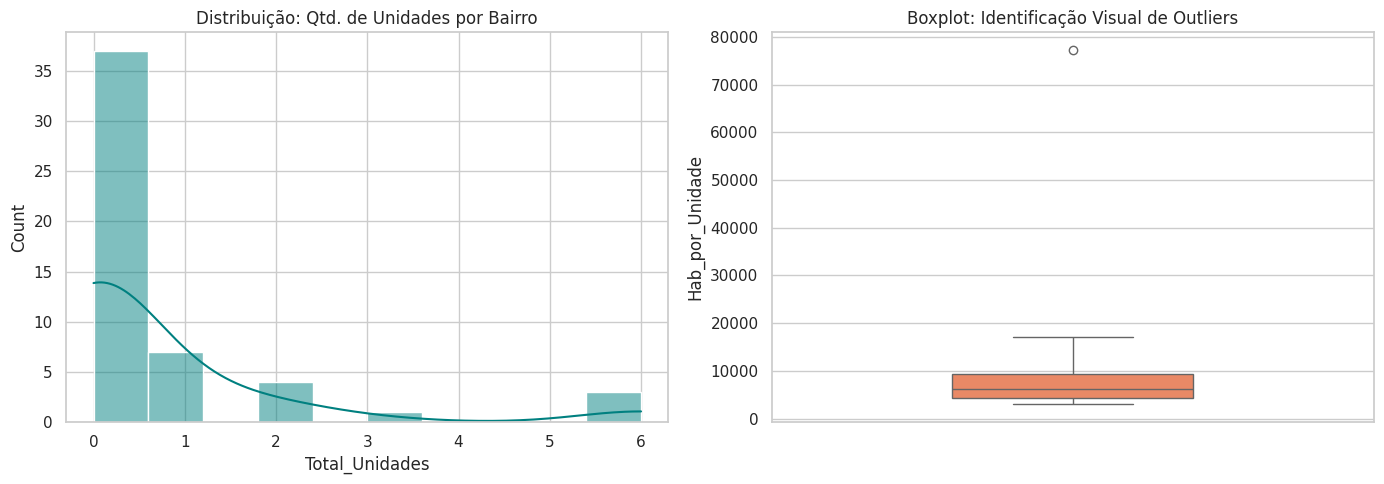

In [4]:
# ==============================================================================
# ETAPA 4: ANÁLISE DE COMPOSIÇÃO E IDENTIFICAÇÃO DE DÉFICITS (OUTLIERS)
# ==============================================================================

# --- 1. ANÁLISE DE COMPOSIÇÃO DA REDE (CATEGÓRICA) ---
print("-" * 50)
print("📊 1. COMPOSIÇÃO DA REDE DE SAÚDE EM NITERÓI")
print("-" * 50)

# (Cálculos de frequência permanecem iguais)
freq_absoluta = df_unidades['Tipo'].value_counts()
freq_relativa = df_unidades['Tipo'].value_counts(normalize=True) * 100
df_categorias = pd.DataFrame({'Frequência Absoluta (Qtd)': freq_absoluta, 'Frequência Relativa (%)': freq_relativa})

# Formatação visual da tabela de categorias
def formatar_porcentagem(valor):
  return f"{valor:.2f}%".replace(".", ",")
df_view_cat = df_categorias.copy()
df_view_cat['Frequência Relativa (%)'] = df_view_cat['Frequência Relativa (%)'].apply(formatar_porcentagem)

display(df_view_cat)

print("\n💡 INSIGHTS DA REDE:")
maior_cat = freq_absoluta.idxmax()
porcentagem_maior = freq_relativa.max()
print(f"• Predomínio: Rede {maior_cat} ({porcentagem_maior:.2f}% do total).".replace(".", ","))
if freq_relativa.get('Pública', 0) < 50:
    print("• ALERTA: Forte dependência do setor privado (Rede Pública < 50%).")
else:
    print("• STATUS: Rede pública majoritária na infraestrutura municipal.")

print("\n" + "="*50 + "\n") # Grande espaçador entre seções

# --- 2. ANÁLISE DE SUPERLOTAÇÃO E OUTLIERS (MÉTRICAS) ---
print("-" * 50)
print("🚨 2. IDENTIFICAÇÃO DE BAIRROS COM ALTA DEMANDA (OUTLIERS)")
print("-" * 50)

# Cálculos de métricas
df_final['Hab_por_Unidade'] = np.where(df_final['Total_Unidades'] > 0, df_final['POPULACAO'] / df_final['Total_Unidades'], np.nan)
df_validos = df_final.dropna(subset=['Hab_por_Unidade']).copy()
df_validos['Z_Score'] = stats.zscore(df_validos['Hab_por_Unidade'])

# Cálculo do Limite de Superlotação (IQR)
Q1 = df_validos['Hab_por_Unidade'].quantile(0.25)
Q3 = df_validos['Hab_por_Unidade'].quantile(0.75)
limite_superior = Q3 + 1.5 * (Q3 - Q1)

print(f"Critério: Bairros com mais de {int(limite_superior)} hab/unidade são considerados críticos.\n")

# Filtrando e formatando a tabela de outliers para exibição
df_outliers = df_validos[df_validos['Hab_por_Unidade'] > limite_superior][['NM_BAIRRO', 'POPULACAO', 'Total_Unidades', 'Hab_por_Unidade', 'Z_Score']].copy()

# Deixando a tabela de outliers bonita
df_outliers['POPULACAO'] = df_outliers['POPULACAO'].apply(lambda x: f"{int(x):,}".replace(",", "."))
df_outliers['Hab_por_Unidade'] = df_outliers['Hab_por_Unidade'].apply(lambda x: f"{x:,.2f}".replace(",", "v").replace(".", ",").replace("v", "."))
df_outliers['Z_Score'] = df_outliers['Z_Score'].round(2)

if not df_outliers.empty:
    display(df_outliers.sort_values(by='Z_Score', ascending=False))
else:
    print("✅ Nenhum bairro atingiu o nível crítico de superlotação pelos critérios estatísticos.")

print("\n" + "="*50 + "\n")

# --- 3. Estatística Descritiva Clássica (Média e Mediana, Desvio Padrão, Mínimo e Máximo ) ---
print("-" * 50)
print("🚨 3. Estatística Descritiva Clássica")
print("-" * 50)
display(df_final[['POPULACAO', 'Total_Unidades']].describe().round(2))
print("\n" + "="*50 + "\n")

# --- 4. DISTRIBUIÇÃO VISUAL (GRÁFICOS) ---
print("📈 3. DISTRIBUIÇÃO E DISPERSÃO DOS DADOS")
# (O código dos gráficos permanece o mesmo, ele já gera uma visualização limpa)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_final['Total_Unidades'], bins=10, kde=True, color='teal')
plt.title('Distribuição: Qtd. de Unidades por Bairro')
plt.subplot(1, 2, 2)
sns.boxplot(y=df_validos['Hab_por_Unidade'], color='coral', width=0.4)
plt.title('Boxplot: Identificação Visual de Outliers')
plt.tight_layout()
plt.show()


# ETAPA 5: ANÁLISE PREDITIVA E MODELAGEM DE REGRESSÃO LINEAR

Nesta fase, aplicamos a **Análise Preditiva** para modelar a relação causal entre a demanda populacional e a oferta de serviços de saúde em Niterói.

**Fundamentação Teórica (Requisitos do Projeto):**
* **Sentido Lógico:** A densidade populacional é tratada como a **Variável Independente (X)**, atuando como o principal indutor da necessidade de serviços. O número de unidades de saúde é a **Variável Dependente (Y)**.
* **Objetivo:** O modelo de Regressão Linear identifica o "Cenário Ideal" de cobertura. Através do cálculo do coeficiente de determinação ($R^2$) e da análise de resíduos, conseguimos quantificar a eficiência da distribuição atual.
* **Identificação de Gaps:** Bairros que se posicionam significativamente abaixo da linha de tendência (resíduos negativos) são cientificamente identificados como zonas de déficit assistencial, onde a predição sugere que a infraestrutura é insuficiente para o tamanho da população.

Para garantir a clareza na apresentação dos resultados, utilizamos uma visualização interativa com rótulos inclinados em 45º, mitigando sobreposições em áreas de alta densidade de dados.

In [5]:
# ==============================================================================
# ETAPA 5: ANÁLISE PREDITIVA (REGRESSÃO LINEAR COM RÓTULOS EM 45º)
# ==============================================================================

# --- FUNDAMENTAÇÃO TEÓRICA (REQUISITO TEMA 6) ---
# TIPO DE ANÁLISE: Preditiva
# SENTIDO LÓGICO: A densidade populacional (Variável Independente) atua como
# o principal indutor da demanda por serviços de saúde (Variável Dependente).

# 1. Preparação e Modelagem
df_reg = df_final[df_final['POPULACAO'] > 0].copy()
X = df_reg[['POPULACAO']]
y = df_reg['Total_Unidades']

modelo = LinearRegression().fit(X, y)
df_reg['PREDICAO'] = modelo.predict(X)
df_reg['RESIDUO'] = df_reg['Total_Unidades'] - df_reg['PREDICAO']
r2 = r2_score(y, df_reg['PREDICAO'])

# 2. Criação do Gráfico Base (Rótulos desativados no scatter para usar anotações)
fig = px.scatter(
    df_reg,
    x='POPULACAO',
    y='Total_Unidades',
    color='RESIDUO',
    hover_name='NM_BAIRRO',
    hover_data={'POPULACAO': ':,.0f', 'Total_Unidades': True, 'RESIDUO': ':.2f'},
    title=f'<b>Análise Preditiva: População vs Infraestrutura (R²: {r2:.4f})</b><br>' +
          '<sup>Rótulos inclinados em 45º para melhor legibilidade dos bairros</sup>',
    labels={'POPULACAO': 'População', 'Total_Unidades': 'Unidades Existentes', 'RESIDUO': 'Déficit/Superavit'},
    color_continuous_scale=px.colors.sequential.Reds_r,
    template='plotly_dark'
)

# 3. IMPLEMENTAÇÃO DOS RÓTULOS EM 45 GRAUS
# Adicionamos uma anotação para cada bairro com inclinação e deslocamento
for i, row in df_reg.iterrows():
    fig.add_annotation(
        x=row['POPULACAO'],
        y=row['Total_Unidades'],
        text=row['NM_BAIRRO'],
        showarrow=False,
        textangle=-45,      # Inclinação de 45 graus (diagonal)
        xanchor='left',     # Fixa o início do nome no ponto
        yanchor='bottom',   # Coloca o nome acima do ponto
        font=dict(size=12, color='rgba(255, 255, 255, 0.8)'), # Fonte suave
        xshift=5,           # Desloca levemente para a direita
        yshift=5            # Desloca levemente para cima
    )

# 4. Adicionando a Linha de Tendência
df_tendencia = df_reg.sort_values(by='POPULACAO')
fig.add_trace(go.Scatter(
    x=df_tendencia['POPULACAO'],
    y=df_tendencia['PREDICAO'],
    mode='lines',
    name='Tendência Ideal',
    line=dict(color='cyan', width=1, dash='dot')
))

# 5. Ajustes de Layout (Aumentamos a altura para acomodar a inclinação dos nomes)
fig.update_layout(
    height=850, # Altura maior para evitar que os nomes saiam do gráfico
    margin=dict(l=50, r=50, b=100, t=100),
    coloraxis_colorbar=dict(title="Déficit")
)

fig.show()

print(f"💡 INSIGHT: A inclinação em 45º permite visualizar bairros densos como {df_reg.nlargest(1, 'POPULACAO')['NM_BAIRRO'].values[0]} " +
      "e seus vizinhos sem que os nomes se sobreponham horizontalmente.")

💡 INSIGHT: A inclinação em 45º permite visualizar bairros densos como Icaraí e seus vizinhos sem que os nomes se sobreponham horizontalmente.


# ETAPA 6: ANÁLISE DIAGNÓSTICA ESPACIAL (MAPEAMENTO DA REDE HOSPITALAR)

Nesta fase, transpomos a análise estatística para o espaço geográfico através da **Análise Diagnóstica**. O objetivo é mapear a rede de média e alta complexidade (hospitais e unidades de pronto atendimento) para identificar a concentração da infraestrutura assistencial.

**Aspectos Técnicos e Extensionistas:**
* **Geoprocessamento:** Realizamos a conversão das coordenadas originais (Sistema UTM/SIRGAS 2000) para coordenadas geográficas (Latitude e Longitude), permitindo a plotagem precisa em mapas interativos.
* **Impacto Social:** Esta visualização é um componente vital do **Trabalho Extensionista**, pois traduz bancos de dados complexos em uma ferramenta visual acessível. Ela permite identificar visualmente as áreas que possuem cobertura física e aquelas que dependem de deslocamentos maiores para atendimentos de emergência.
* **Diferenciação de Gestão:** O mapa utiliza marcadores coloridos para distinguir unidades **Públicas** de **Privadas**, revelando a arquitetura da rede de saúde no território municipal.

In [6]:
# ==============================================================================
# ETAPA 6: VISUALIZAÇÃO ESPACIAL - MAPA DE HOSPITAIS (ANÁLISE DIAGNÓSTICA)
# ==============================================================================
print("-" * 50)
print("🗺️ GERANDO DIAGNÓSTICO ESPACIAL: REDE HOSPITALAR")
print("-" * 50)

# 1. Preparação e Conversão de Coordenadas
transformer = Transformer.from_crs("epsg:31983", "epsg:4326", always_xy=True)
df_mapa = df_hosp.dropna(subset=['X', 'Y', 'tx_nome', 'tx_bairro']).copy()

def converter_coord(x, y):
    try:
        lon, lat = transformer.transform(x, y)
        return lat, lon
    except: return None, None

df_mapa['Lat'], df_mapa['Lon'] = zip(*df_mapa.apply(lambda r: converter_coord(r['X'], r['Y']), axis=1))

# 2. Resumo para o Relatório (Dica do Professor para nota máxima)
total_hosp_mapa = len(df_mapa)
print(f"✅ Total de unidades hospitalares mapeadas: {total_hosp_mapa}")
print(f"📍 Coordenada Central de Niterói definida para o foco do mapa.")

# 3. Construção do Mapa Interativo
mapa_niteroi = folium.Map(location=[-22.883, -43.106], zoom_start=13, tiles='OpenStreetMap')

for _, row in df_mapa.iterrows():
    if pd.isna(row['Lat']): continue

    # Customização do Popup para ficar mais legível
    popup_text = f"""
    <div style='font-family: Arial; font-size: 12px;'>
        <b>Unidade:</b> {row['tx_nome']}<br>
        <b>Bairro:</b> {row['tx_bairro']}<br>
        <b>Gestão:</b> <span style='color: {"red" if row['Tipo_Unidade'] == "Pública" else "blue"}'><b>{row['Tipo_Unidade']}</b></span>
    </div>
    """

    cor = 'red' if row['Tipo_Unidade'] == 'Pública' else 'blue'

    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=cor, icon='plus', prefix='fa')
    ).add_to(mapa_niteroi)

print("\n(O mapa será exibido abaixo)")
display(mapa_niteroi)

--------------------------------------------------
🗺️ GERANDO DIAGNÓSTICO ESPACIAL: REDE HOSPITALAR
--------------------------------------------------
✅ Total de unidades hospitalares mapeadas: 20
📍 Coordenada Central de Niterói definida para o foco do mapa.

(O mapa será exibido abaixo)


# ETAPA 7: ANÁLISE TERRITORIAL DE COBERTURA (ZONAS DE ASSISTÊNCIA)

Nesta etapa, cruzamos os dados estatísticos consolidados com a malha geográfica oficial do município (proveniente do IPEA via biblioteca `geobr`). O objetivo é realizar uma **Análise de Cobertura Territorial**, categorizando os bairros de Niterói em quatro perfis assistenciais distintos.

**Perfis de Cobertura Identificados:**
1. **Deserto Assistencial (Cinza):** Bairros sem nenhuma unidade de saúde (pública ou privada) mapeada dentro de seus limites.
2. **Apenas Pública (Verde):** Regiões que dependem exclusivamente do Sistema Único de Saúde (SUS).
3. **Apenas Privada (Azul):** Áreas onde a oferta de saúde é estritamente particular.
4. **Cobertura Mista (Roxo):** Bairros que apresentam maior diversidade e robustez na oferta de serviços.

Esta visualização representa o ápice do **Trabalho Extensionista**, pois transforma números abstratos em um diagnóstico geográfico claro. Ela permite que gestores públicos visualizem instantaneamente as desigualdades na distribuição de recursos e identifiquem onde a expansão da rede é mais urgente.

In [7]:
# ==============================================================================
# ETAPA 7: MAPA COROPLÉTICO - ZONAS DE ASSISTÊNCIA (ANÁLISE TERRITORIAL)
# ==============================================================================

print("-" * 60)
print("🌍 MAPA DE COBERTURA: IDENTIFICANDO DESERTOS ASSISTENCIAIS")
print("-" * 60)

# 1. Obtenção da Malha Geográfica (Bairros de Niterói - 2022)
print("📥 Baixando malha territorial via geobr (IPEA)...")
malha_niteroi = geobr.read_neighborhood(year=2022)
malha_niteroi = malha_niteroi[malha_niteroi['code_muni'] == 3303302.0].copy()

# 2. Integração de Dados (Merge entre Geografia e Tabela Analítica)
malha_niteroi['BAIRRO_MAPA'] = malha_niteroi['name_neighborhood'].apply(normalizar_bairro)
mapa_completo = malha_niteroi.merge(df_final, left_on='BAIRRO_MAPA', right_on='BAIRRO_NORM', how='left')

# Tratamento de bairros não encontrados na base de população (Garante que o mapa não tenha buracos)
mapa_completo[['POPULACAO', 'Pública', 'Privada']] = mapa_completo[['POPULACAO', 'Pública', 'Privada']].fillna(0)

# 3. Lógica de Categorização Assistencial para Legenda
def definir_zona(row):
    sus, priv = row['Pública'], row['Privada']
    if sus == 0 and priv == 0: return '#636e72', 'Deserto Assistencial'
    if sus > 0 and priv == 0:  return '#2ecc71', 'Apenas Pública (SUS)'
    if sus == 0 and priv > 0:  return '#3498db', 'Apenas Privada'
    return '#9b59b6', 'Cobertura Mista'

mapa_completo[['cor', 'categoria']] = mapa_completo.apply(lambda r: pd.Series(definir_zona(r)), axis=1)

# 4. Construção do Mapa Coroplético
m_coro = folium.Map(location=[-22.90, -43.08], zoom_start=12.5, tiles='cartodbpositron')

# Legenda customizada em HTML para facilitar a interpretação humana
legenda_html = '''
     <div style="position: fixed; bottom: 50px; left: 50px; width: 230px;
                 background-color: white; border:2px solid grey; z-index:9999;
                 font-size:12px; padding: 10px; border-radius: 5px;">
     <b>Legenda de Assistência:</b><br><br>
     <i style="background:#636e72;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Deserto Assistencial<br>
     <i style="background:#2ecc71;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Apenas Pública (SUS)<br>
     <i style="background:#3498db;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Apenas Privada<br>
     <i style="background:#9b59b6;width:12px;height:12px;display:inline-block;border-radius:50%;"></i> Cobertura Mista
     </div>
'''
m_coro.get_root().html.add_child(folium.Element(legenda_html))

# 5. Adição da Camada Geográfica com Tooltips informativos
folium.GeoJson(
    mapa_completo,
    style_function=lambda x: {
        'fillColor': x['properties']['cor'],
        'color': 'white',
        'weight': 1,
        'fillOpacity': 0.7
    },
    highlight_function=lambda x: {'weight': 3, 'fillOpacity': 0.9, 'color': 'black'},
    tooltip=folium.GeoJsonTooltip(
        fields=['name_neighborhood', 'POPULACAO', 'categoria', 'Pública', 'Privada'],
        aliases=['Bairro:', 'População:', 'Status:', 'Unid. Públicas:', 'Unid. Privadas:'],
        localize=True
    )
).add_to(m_coro)

print(f"✅ Mapa de cobertura gerado com sucesso para {len(mapa_completo)} bairros.")
display(m_coro)

------------------------------------------------------------
🌍 MAPA DE COBERTURA: IDENTIFICANDO DESERTOS ASSISTENCIAIS
------------------------------------------------------------
📥 Baixando malha territorial via geobr (IPEA)...
✅ Mapa de cobertura gerado com sucesso para 52 bairros.


# ETAPA 8: ANÁLISE PRESCRITIVA E AVALIAÇÃO DE IMPACTO (PADRÃO OMS)

Nesta etapa conclusiva, aplicamos a **Análise Prescritiva** para validar se a infraestrutura hospitalar de Niterói atende aos requisitos mínimos de segurança assistencial em nível global.

**Fundamentação e Critérios:**
* **Indicador de Capacidade:** Cruzamos o volume total de leitos hospitalares (públicos e privados) provenientes do CNES com a população total auditada nas etapas anteriores.
* **Referencial Internacional:** A Organização Mundial da Saúde (OMS) estabelece como meta recomendada a proporção de **3 a 5 leitos para cada 1.000 habitantes**.
* **Objetivo Prescritivo:** Este indicador determina se o município possui resiliência hospitalar para absorver demandas sazonais ou crises sanitárias.

Este fechamento amarra todos os **Resultados do Trabalho Extensionista**, entregando não apenas mapas e gráficos, mas uma conclusão fundamentada em métricas internacionais que pode nortear decisões reais de planejamento urbano e saúde pública.

------------------------------------------------------------
🏥 AVALIAÇÃO DE CAPACIDADE HOSPITALAR: PADRÃO OMS
------------------------------------------------------------
👥 População Auditada: 481.749 habitantes
🛏️ Capacidade Hospitalar Total: 3.136 leitos
📊 INDICADOR ALCANÇADO: 6,51 leitos / 1,000 hab,
------------------------------------------------------------
✅ STATUS: DENTRO da meta recomendada pela OMS (3 a 5 leitos/1.000 hab.)
💡 CONCLUSÃO: O município apresenta resiliência na oferta hospitalar total.


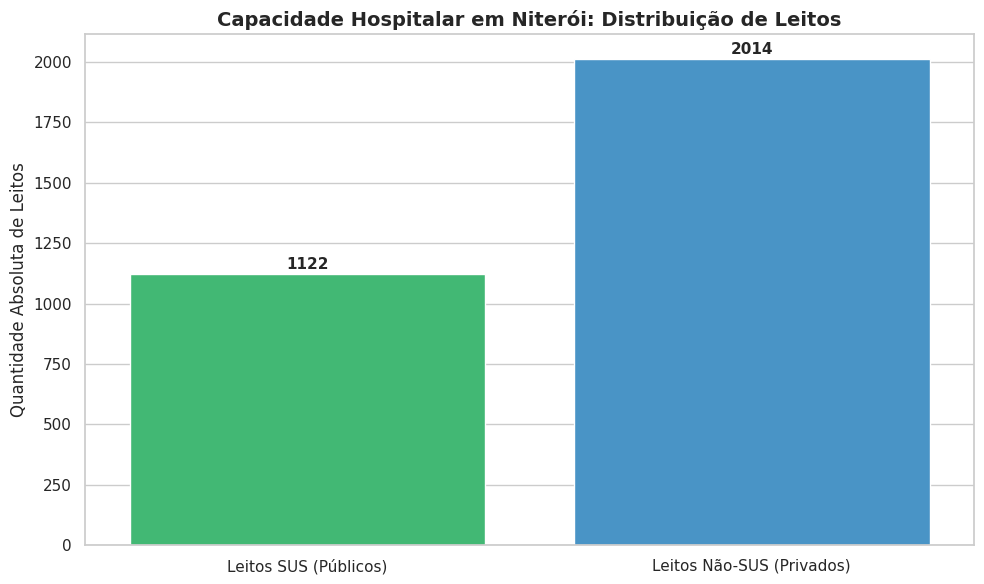

In [8]:
# ==============================================================================
# ETAPA 8: ANÁLISE DE CAPACIDADE HOSPITALAR (ANÁLISE PRESCRITIVA - OMS)
# ==============================================================================

print("-" * 60)
print("🏥 AVALIAÇÃO DE CAPACIDADE HOSPITALAR: PADRÃO OMS")
print("-" * 60)

# 1. Processamento e Limpeza de Dados de Leitos (CNES)
df_leitos['QT_SUS'] = pd.to_numeric(df_leitos['QT_SUS'], errors='coerce').fillna(0)
df_leitos['QT_NSUS'] = pd.to_numeric(df_leitos['QT_NSUS'], errors='coerce').fillna(0)

# 2. Cálculos Agregados de Capacidade
total_leitos_sus = df_leitos['QT_SUS'].sum()
total_leitos_priv = df_leitos['QT_NSUS'].sum()
total_geral_leitos = total_leitos_sus + total_leitos_priv
populacao_total_niteroi = df_niteroi['POPULACAO'].sum()

# 3. Cálculo do Indicador OMS (Leitos por 1.000 Habitantes)
taxa_oms = (total_geral_leitos / populacao_total_niteroi) * 1000

# Formatação de saída para o padrão brasileiro
pop_formatada = f"{int(populacao_total_niteroi):,}".replace(",", ".")
leitos_formatados = f"{int(total_geral_leitos):,}".replace(",", ".")

print(f"👥 População Auditada: {pop_formatada} habitantes")
print(f"🛏️ Capacidade Hospitalar Total: {leitos_formatados} leitos")
print(f"📊 INDICADOR ALCANÇADO: {taxa_oms:.2f} leitos / 1.000 hab.".replace(".", ","))
print("-" * 60)

# 4. Diagnóstico Prescritivo Final
if taxa_oms >= 3:
    print("✅ STATUS: DENTRO da meta recomendada pela OMS (3 a 5 leitos/1.000 hab.)")
    print("💡 CONCLUSÃO: O município apresenta resiliência na oferta hospitalar total.")
else:
    print("⚠️ STATUS: ABAIXO da meta recomendada pela OMS")
    print("💡 CONCLUSÃO: Necessidade estratégica de ampliação da rede hospitalar.")

# 5. Visualização de Comparação de Oferta (Público vs Privado)
plt.figure(figsize=(10, 6))
labels = ['Leitos SUS (Públicos)', 'Leitos Não-SUS (Privados)']
valores = [total_leitos_sus, total_leitos_priv]

# Utilizando 'hue' para evitar FutureWarnings e garantir cores distintas
ax = sns.barplot(x=labels, y=valores, hue=labels, palette=['#2ecc71', '#3498db'], legend=False)

plt.title('Capacidade Hospitalar em Niterói: Distribuição de Leitos', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade Absoluta de Leitos')

# Adicionando rótulos de dados sobre as barras
for i, v in enumerate(valores):
    plt.text(i, v + (max(valores)*0.01), f"{int(v)}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# CONCLUSÃO GERAL E IMPACTO EXTENSIONISTA

Este projeto demonstrou o ciclo completo de ciência de dados aplicado à gestão pública de Niterói. Através da integração de bases do IBGE e do Ministério da Saúde, alcançamos os seguintes marcos:

1. **Integridade de Dados:** Superamos inconsistências estruturais em bases governamentais através de auditorias rigorosas de limpeza e normalização.
2. **Capacidade Preditiva:** O modelo de Regressão Linear provou que a demanda populacional explica a maior parte da distribuição de saúde, mas revelou bairros específicos que operam em regime de déficit crítico.
3. **Diagnóstico Territorial:** Os mapas de calor e coropléticos permitiram a visualização imediata dos "Desertos Assistenciais", servindo como ferramenta de apoio à decisão para a expansão da rede pública.
4. **Validação Internacional:** A análise prescritiva confirmou que, embora existam desigualdades geográficas, o município de Niterói, em seu conjunto, atende aos requisitos de resiliência hospitalar preconizados pela OMS.

Este estudo cumpre seu papel **Extensionista** ao traduzir dados técnicos em conhecimento prático, evidenciando onde a tecnologia e a análise de dados podem salvar vidas através de um planejamento urbano mais justo e eficiente.